# Iris Flower Classification

In this notebook, we build a multiclass classification model on the famous **Iris dataset**.

We will:
- Load the dataset
- Explore the features and target classes
- Visualize the data
- Split into train and test sets
- Train a K-Nearest Neighbors (KNN) classifier
- Evaluate performance
- Compare with Logistic Regression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set(style="whitegrid")

## 1. Load the dataset

The Iris dataset is built into scikit-learn.

It contains:
- 150 samples
- 4 features:
  - sepal length
  - sepal width
  - petal length
  - petal width
- 3 target classes:
  - setosa
  - versicolor
  - virginica

In [2]:
iris = load_iris(as_frame=True)

df = iris.frame.copy()
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2. Basic inspection

We check:
- shape of the dataset
- feature names
- target names
- summary statistics

In [3]:
print("Shape:", df.shape)
print("\nFeature names:\n", iris.feature_names)
print("\nTarget names:\n", iris.target_names)
print("\nMissing values:\n", df.isnull().sum())

Shape: (150, 5)

Feature names:
 ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target names:
 ['setosa' 'versicolor' 'virginica']

Missing values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64


In [4]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 3. Separate features and target

We split the dataset into:
- `X` = feature columns
- `y` = target column

In [5]:
X = df.drop("target", axis=1)
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


## 4. Check class distribution

We inspect how many samples belong to each flower class.

In [6]:
class_counts = y.value_counts().sort_index()
for idx, count in class_counts.items():
    print(f"{iris.target_names[idx]}: {count}")

setosa: 50
versicolor: 50
virginica: 50


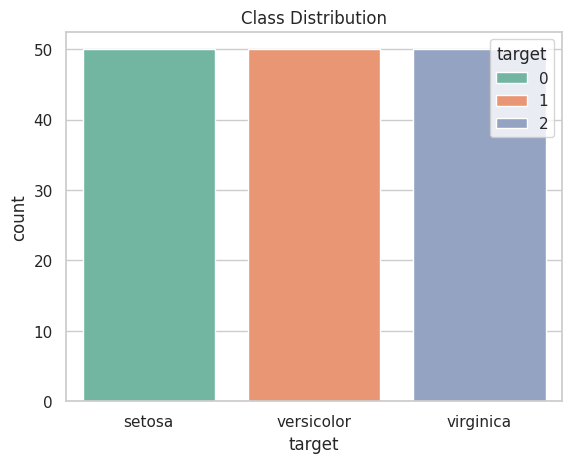

In [7]:
sns.countplot(x=y, hue=y, palette="Set2")
plt.xticks([0, 1, 2], iris.target_names)
plt.title("Class Distribution")
plt.show()

## 5. Quick visualization

We use a pairplot to visually inspect how the flower classes separate.

This helps us understand whether the classes are easy or hard to classify.

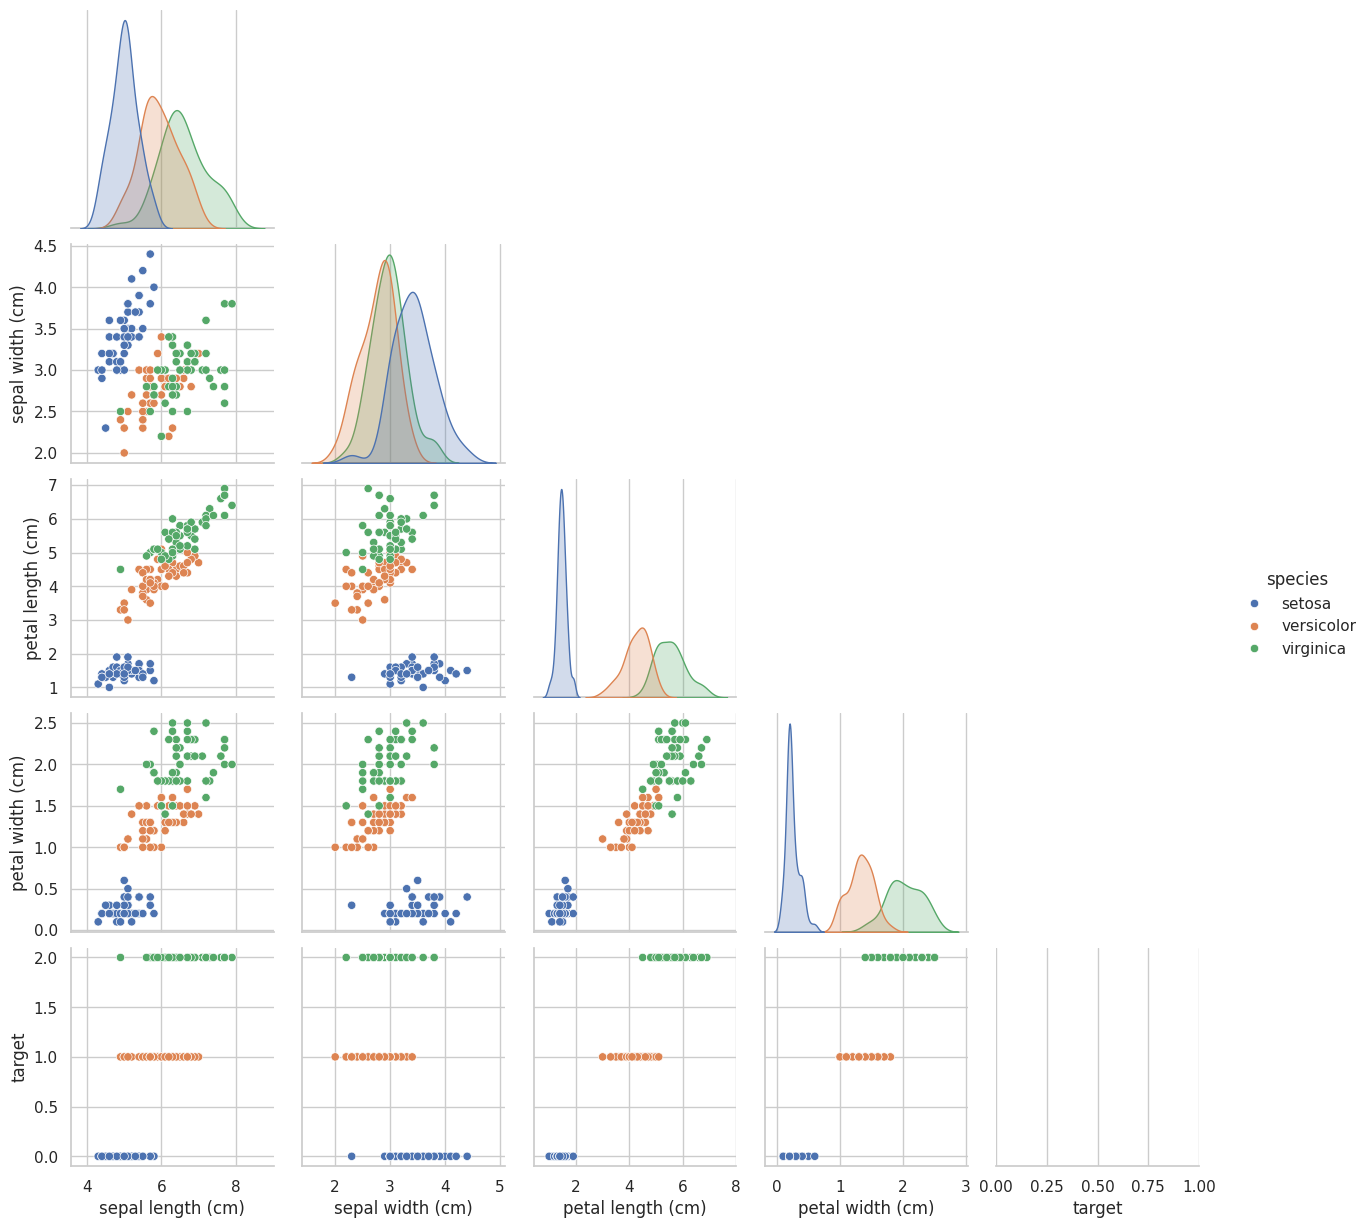

In [8]:
plot_df = df.copy()
plot_df["species"] = plot_df["target"].map({
    0: iris.target_names[0],
    1: iris.target_names[1],
    2: iris.target_names[2]
})

sns.pairplot(plot_df, hue="species", corner=True)
plt.show()

## 6. Train-test split

We split the dataset into:
- 80% training data
- 20% test data

We use `stratify=y` so each class is represented proportionally in both sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (120, 4)
X_test : (30, 4)


## 7. First model: K-Nearest Neighbors (KNN)

We start with **KNN**, a simple and intuitive classification model.

Since KNN is distance-based, feature scaling is important.
So we use:
- `StandardScaler`
- `KNeighborsClassifier`
inside a pipeline

In [10]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

knn_pipeline.fit(X_train, y_train)

y_pred_knn = knn_pipeline.predict(X_test)

## 8. Evaluate KNN

We evaluate using:
- Accuracy
- Confusion matrix
- Classification report

In [11]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", round(knn_accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_knn, target_names=iris.target_names))

KNN Accuracy: 0.9333

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



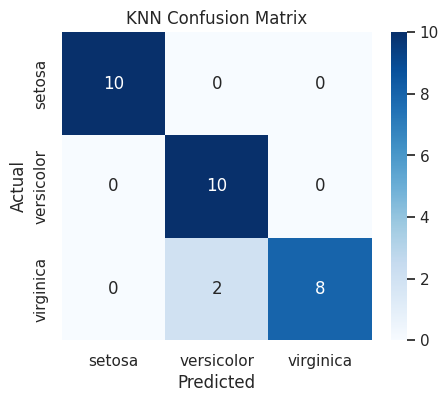

In [12]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

## 9. Second model: Logistic Regression

Now we compare KNN with a multiclass Logistic Regression model.

This gives us practice with another common classifier and lets us compare results.

In [13]:
logreg_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)

## 10. Evaluate Logistic Regression

In [14]:
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
print("Logistic Regression Accuracy:", round(logreg_accuracy, 4))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_logreg, target_names=iris.target_names))

Logistic Regression Accuracy: 0.9333

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



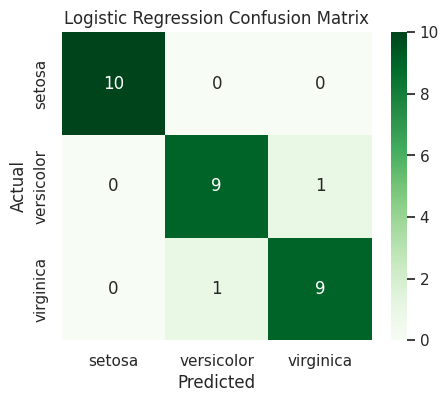

In [15]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Greens",
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

## 11. Compare both models

We compare the accuracy of KNN and Logistic Regression side by side.

In [16]:
results = pd.DataFrame({
    "Model": ["KNN", "Logistic Regression"],
    "Accuracy": [knn_accuracy, logreg_accuracy]
})

results

,Model,Accuracy
0,KNN,0.933333
1,Logistic Regression,0.933333


## 12. Make a sample prediction

We take one sample from the test set and predict its class using KNN.

In [17]:
sample = X_test.iloc[[0]]
sample_pred = knn_pipeline.predict(sample)[0]

print("Sample features:\n")
display(sample)

print("Actual class   :", iris.target_names[y_test.iloc[0]])
print("Predicted class:", iris.target_names[sample_pred])

Sample features:



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
38,4.4,3.0,1.3,0.2


Actual class   : setosa
Predicted class: setosa


## 13. What this notebook helped revise

This notebook covers:
- multiclass classification
- train-test split
- feature scaling
- KNN classifier
- Logistic Regression classifier
- confusion matrix
- classification report
- comparing models
